In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import sqlite3 as sq

In [2]:
conn = sq.connect("my_marvel.db")

In [3]:
comics_df = pd.read_sql_query("select * from comics",conn)

In [4]:
characters_df = pd.read_sql_query("select * from characters",conn)

In [5]:
char_comics_df = pd.read_sql_query("select * from character_comics",conn)

In [6]:
characters_df.head(10)

,id,name,description
0,1009144,A.I.M.,AIM is a terrorist organization bent on destro...
1,1009146,Abomination (Emil Blonsky),"Formerly known as Emil Blonsky, a spy of Sovie..."
2,1009148,Absorbing Man,
3,1009149,Abyss,
4,1009150,Agent Zero,
5,1009151,Amiko,
6,1009152,Ancient One,
7,1009153,Angel (Warren Worthington III),
8,1009154,Annihilus,
9,1009155,Ant-Man (Hank Pym),


In [7]:
comics_df.head(10)

,id,title,issueNumber
0,2,Pulse (2004) #6,6.0
1,3,THE PULSE: THIN AIR (Trade Paperback),1.0
2,4,Rogue (2004) #5,5.0
3,5,Spectacular Spider-Man (2003) #21,21.0
4,6,Amazing Spider-Man (1999) #514,514.0
5,9,Fantastic Four (1998) #520,520.0
6,10,Mystique (2003) #21,21.0
7,11,X-Men (2004) #164,164.0
8,12,Ultimate Spider-Man (2000) #68,68.0
9,13,Ultimate Spider-Man (2000) #69,69.0


In [8]:
char_comics_df.head(10)

,character_id,comic_id
0,1017100,47176
1,1017100,40628
2,1017100,40630
3,1017100,40632
4,1009144,103120
5,1009144,103371
6,1009144,92308
7,1009144,92307
8,1009144,65941
9,1009144,65466


In [9]:
char_comics_df.describe

<bound method NDFrame.describe of        character_id  comic_id
0           1017100     47176
1           1017100     40628
2           1017100     40630
3           1017100     40632
4           1009144    103120
...             ...       ...
60534       1011239     20818
60535       1011239     20663
60536       1011239     17617
60537       1011239     17618
60538       1011239     17378

[60539 rows x 2 columns]>

In [10]:
comics_df.shape

(23861, 3)

In [11]:
characters_df.shape

(1564, 3)

In [12]:
char_comics_df.shape

(60539, 2)

In [13]:
print(characters_df['description'].value_counts())

description
                                                                                                                                                                                                                                                                                                                                                                                                        1257
                                                                                                                                                                                                                                                                                                                                                                                                           2
Chase Stein is the son of mad scientists Victor and Janet Stein and is the tech genius of the Runaways.                                                                                           

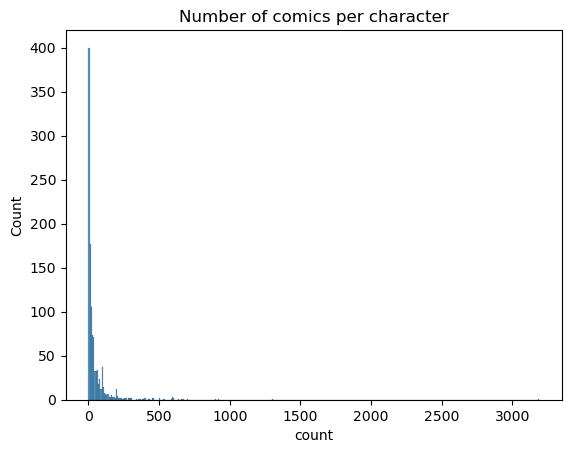

In [14]:
comic_counts = char_comics_df['character_id'].value_counts()
sns.histplot(comic_counts)
plt.title("Number of comics per character")
plt.show()

In [15]:
comic_counts = char_comics_df['character_id'].value_counts().head(10)
top_characters = characters_df[characters_df['id'].isin(comic_counts.index)]
top_characters['comic_count'] = top_characters['id'].map(comic_counts)
print(top_characters[['name', 'comic_count']])

                          name  comic_count
29                       Beast          600
43                 Black Widow          638
92                    Colossus          707
202                     Iceman          599
302               Nightcrawler          661
372                      Rogue          672
434  Spider-Man (Peter Parker)         3190
450                      Storm          924
481                      Thing          899
483                       Thor         1297


/tmp/ipykernel_15055/4057012155.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_characters['comic_count'] = top_characters['id'].map(comic_counts)


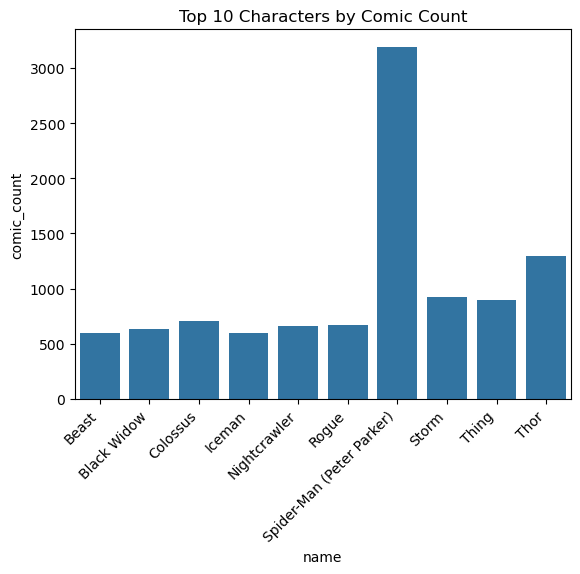

In [16]:
sns.barplot(x='name', y='comic_count', data=top_characters)
plt.xticks(rotation=45, ha='right')
plt.title("Top 10 Characters by Comic Count")
plt.show()

In [19]:
character_comic_count_df = pd.read_sql_query("SELECT c.name as Charcter_Name, COUNT(DISTINCT cc.comic_id) AS Comic_count FROM character_comics AS cc INNER JOIN characters AS c ON c.id = cc.character_id GROUP BY c.name ORDER BY c.name;",conn)

In [18]:
character_comic_count_df.head(100)

,Charcter_Name,Comic_count
0,A-Bomb (HAS),4
1,A.I.M.,53
2,Aaron Stack,14
3,Abomination (Emil Blonsky),58
4,Abomination (Ultimate),2
...,...,...
95,Black Crow,1
96,Black Knight (Dane Whitman),86
97,Black Knight (Sir Percy of Scandia),107
98,Black Panther,100


In [18]:
character_comic_count_df.head(100)

,Charcter_Name,Comic_count
0,A-Bomb (HAS),4
1,A.I.M.,53
2,Aaron Stack,14
3,Abomination (Emil Blonsky),58
4,Abomination (Ultimate),2
...,...,...
95,Black Crow,1
96,Black Knight (Dane Whitman),86
97,Black Knight (Sir Percy of Scandia),107
98,Black Panther,100


In [23]:
character_comic_count_df.shape

(1141, 2)